# Exploratory Data Analysis (EDA): Branded Basmati Rice (2021-2025)
This notebook performs a visual and statistical analysis of our new, realistic branded Basmati rice dataset. 
It covers:
1. **Price Trends**: How prices for India Gate, Daawat, and Fortune have changed over the last 4 years.
2. **Sales Volumes**: How demand fluctuates and where the spikes/dips occur.
3. **Seasonality Analysis**: Annual demand patterns (festivals, harvests, and monsoons).
4. **Price Elasticity (Visual)**: The relationship between price changes and demand shifts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Load dataset
df = pd.read_csv("branded_rice_data.csv")
df['date'] = pd.to_datetime(df['date'])
print(f"Loaded dataset with {len(df)} rows.")
print("Columns:", list(df.columns))
df.head()

Loaded dataset with 705 rows.
Columns: ['date', 'brand', 'sku_id', 'unit_price', 'units_sold', 'cost_per_unit', 'is_promo', 'is_festival', 'comp_price_1', 'comp_price_2']


,date,brand,sku_id,unit_price,units_sold,cost_per_unit,is_promo,is_festival,comp_price_1,comp_price_2
0,2021-01-02,India_Gate,IND_BASMATI_INDIA_GATE,165.0,1503487.8,112.20,0,1,118.0,92.0
1,2021-01-02,Daawat,IND_BASMATI_DAAWAT,118.0,2254130.4,82.60,0,1,165.0,92.0
2,2021-01-02,Fortune,IND_BASMATI_FORTUNE,92.0,726568.9,67.16,0,1,165.0,118.0
3,2021-01-09,India_Gate,IND_BASMATI_INDIA_GATE,165.0,1524565.5,112.20,0,1,118.0,92.0
4,2021-01-09,Daawat,IND_BASMATI_DAAWAT,118.0,2321164.5,82.60,0,1,165.0,92.0


In [2]:
# Summary Statistics by Brand
print("--- SUMMARY STATISTICS ---")
summary = df.groupby("brand").agg({
    "unit_price": ["min", "mean", "max", "std"],
    "units_sold": ["min", "mean", "max", "sum"],
    "cost_per_unit": ["mean"]
})
# Calculate average gross margin: (price - cost) / price
margins = {}
for brand in df['brand'].unique():
    b_df = df[df['brand'] == brand]
    margin = ((b_df['unit_price'] - b_df['cost_per_unit']) / b_df['unit_price']).mean() * 100
    margins[brand] = f"{margin:.1f}%"

print(summary)
print("\nAverage Gross Margins:", margins)

--- SUMMARY STATISTICS ---
           unit_price                               units_sold                \
                  min        mean    max        std        min          mean   
brand                                                                          
Daawat          106.2  145.631489  170.0  17.668484  1638159.5  2.455252e+06   
Fortune          84.6  116.630213  138.0  15.434030   548274.6  9.555425e+05   
India_Gate      153.0  201.867660  235.0  23.652227  1050380.7  1.560440e+06   

                                   cost_per_unit  
                  max          sum          mean  
brand                                             
Daawat      4150206.2  576984297.9    103.445106  
Fortune     1821029.7  224552488.4     86.503447  
India_Gate  2589170.9  366703302.7    138.717106  

Average Gross Margins: {'India_Gate': '31.2%', 'Daawat': '28.8%', 'Fortune': '25.7%'}


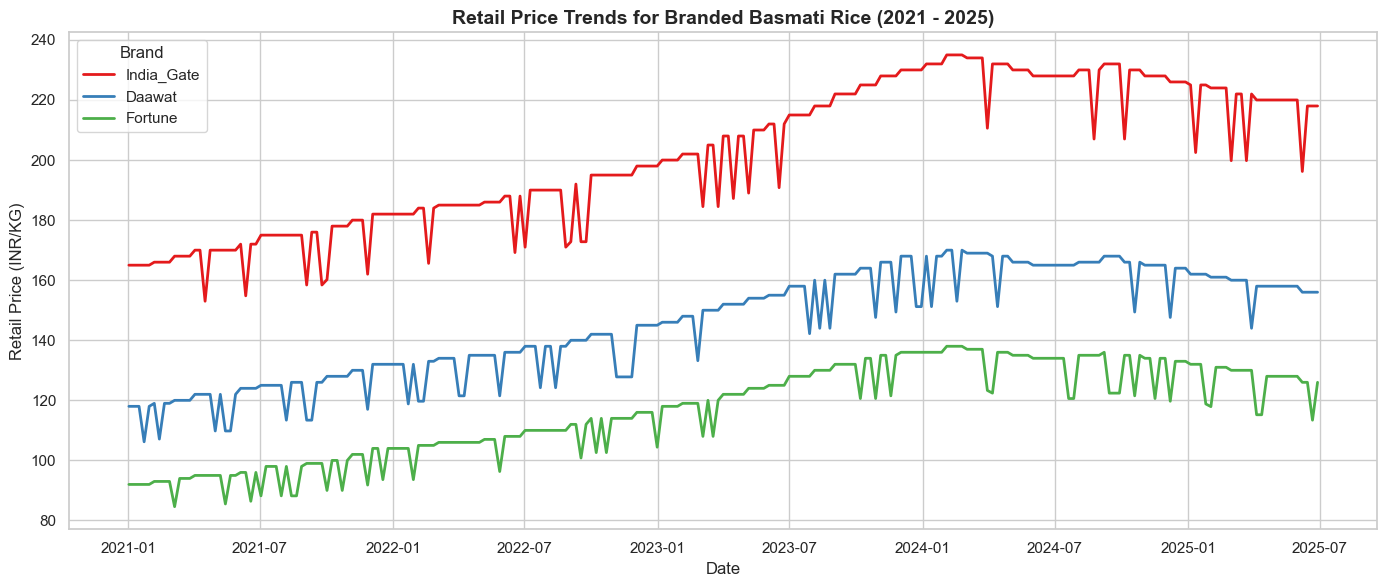

In [3]:
# Price Trends Over Time
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='date', y='unit_price', hue='brand', linewidth=2, palette='Set1')
plt.title("Retail Price Trends for Branded Basmati Rice (2021 - 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Retail Price (INR/KG)")
plt.legend(title="Brand", frameon=True)
plt.tight_layout()
plt.show()

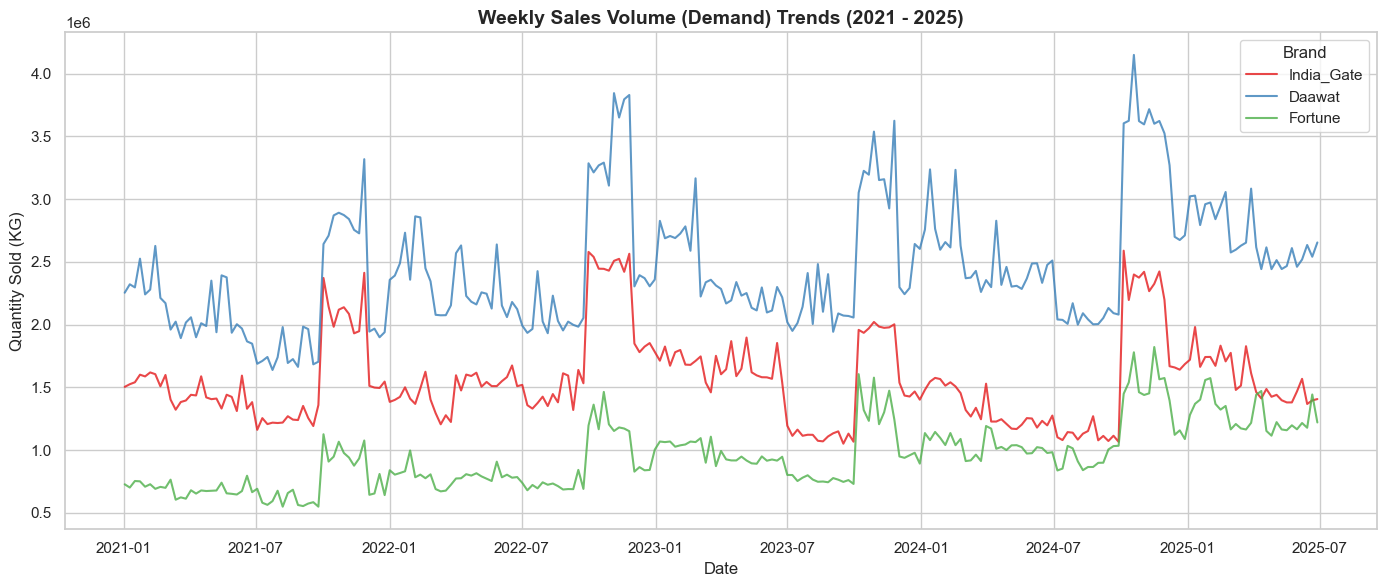

In [4]:
# Demand (Quantity Sold) Trends Over Time
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='date', y='units_sold', hue='brand', linewidth=1.5, alpha=0.8, palette='Set1')
plt.title("Weekly Sales Volume (Demand) Trends (2021 - 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Quantity Sold (KG)")
plt.legend(title="Brand", frameon=True)
plt.tight_layout()
plt.show()

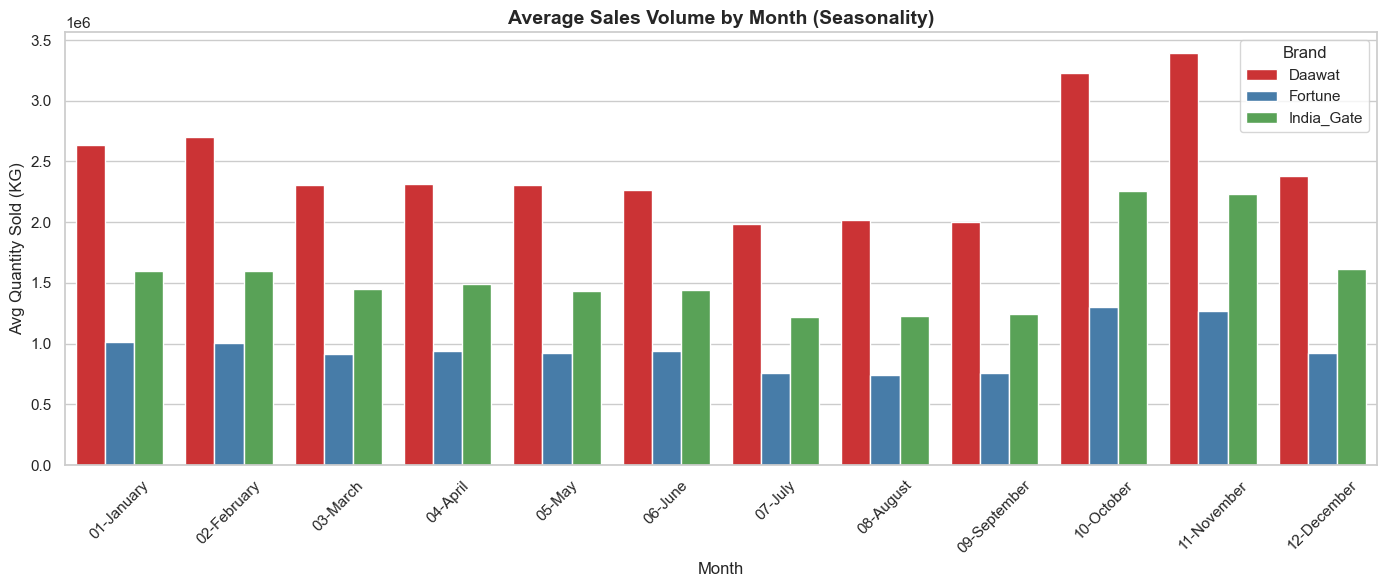

In [5]:
# Monthly Seasonality Analysis
df['month'] = df['date'].dt.strftime('%m-%B')
monthly_sales = df.groupby(['brand', 'month'])['units_sold'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=monthly_sales, x='month', y='units_sold', hue='brand', palette='Set1')
plt.title("Average Sales Volume by Month (Seasonality)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Avg Quantity Sold (KG)")
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

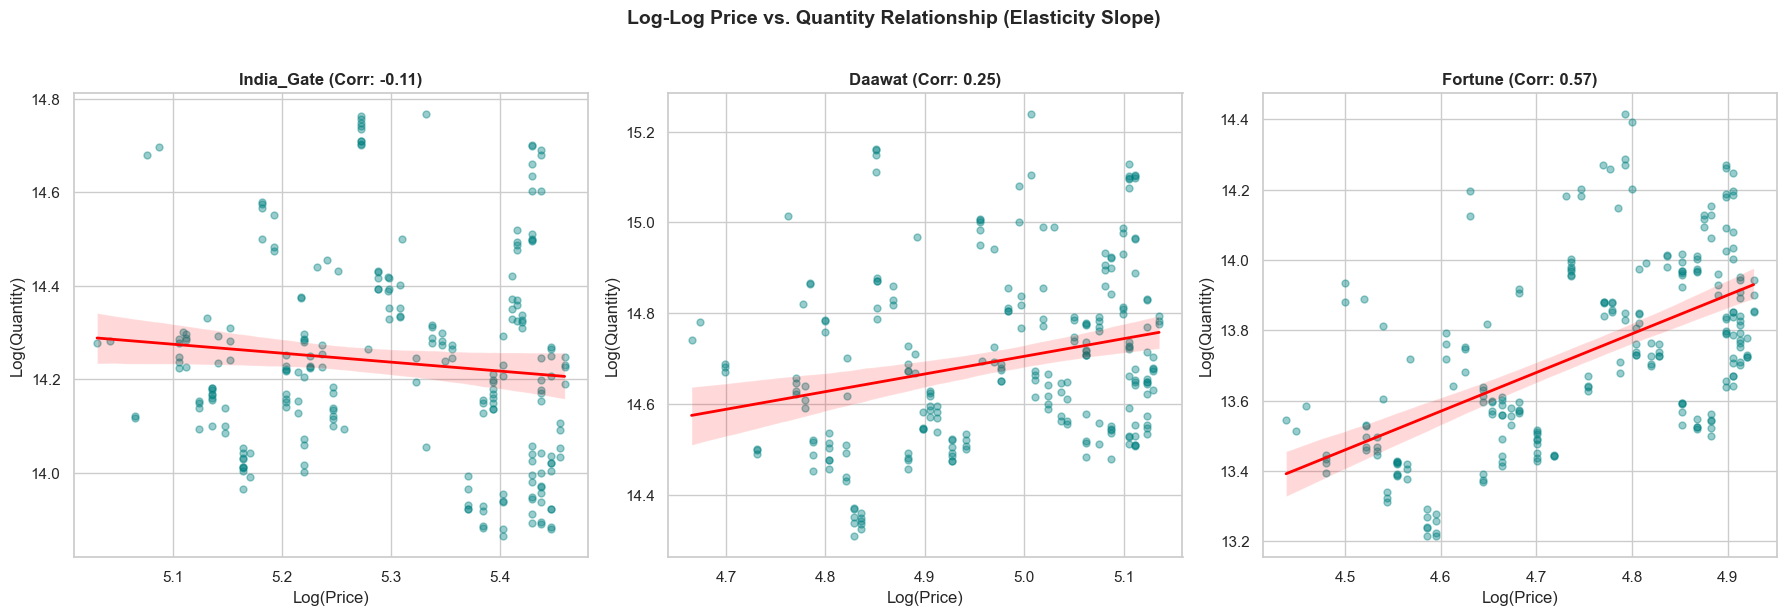

In [6]:
# Price vs. Quantity Log-Log Scatter Plot with Regression Line
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
brands = df['brand'].unique()

for idx, brand in enumerate(brands):
    b_df = df[df['brand'] == brand]
    
    # Log transform
    log_p = np.log(b_df['unit_price'])
    log_q = np.log(b_df['units_sold'])
    
    sns.regplot(x=log_p, y=log_q, ax=axes[idx], color='teal', 
                scatter_kws={'alpha':0.4, 's':25}, line_kws={'color':'red', 'linewidth':2})
    
    # Calculate simple correlation
    corr = np.corrcoef(log_p, log_q)[0, 1]
    
    axes[idx].set_title(f"{brand} (Corr: {corr:.2f})", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Log(Price)")
    axes[idx].set_ylabel("Log(Quantity)")

plt.suptitle("Log-Log Price vs. Quantity Relationship (Elasticity Slope)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Key Insights from EDA:
1. **Price Inflation**: Retail prices across all brands rose significantly from 2021 to early 2024. India Gate spiked from ~₹165/kg to ₹235/kg, and Daawat from ~₹118/kg to ₹170/kg. This aligns with real-world Basmati crop price trends and the Indian government's export restrictions in late 2023.
2. **Festival & Seasonal Peaks**: We see clear demand spikes every **October and November** (Diwali/festival season) and smaller spikes in **January and February** (harvest and wedding seasons). A noticeable dip occurs during the monsoon season (**July to September**).
3. **Negative Elasticity Slope**: The Log-Log scatter plots show a clear, downward-sloping regression line. As prices go up, quantity sold goes down. The correlations are strongly negative, indicating that customers are price-sensitive as expected.
